# Zadanie obowiązkowe [0-10] pkt

Użyj zbioru danych [Yeast](https://archive.ics.uci.edu/dataset/110/yeast) i powtórz kroki z ćwiczeń.


1. [0-2 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów kNN, zmieniając (uargumentuj wybór zakresów):
   1. liczbę sąsiadów
   1. wagę dla sąsiadów
   1. metrykę
1. [0-1.5 pkt] Do wyszukiwania dodaj miary skuteczności m.in. dokładność (*accuracy*) precyzję (*precision*), czułość (*recall*, *sensitivity*), czy też współczynnik korelacji Matthewsa (MCC). Gdzie to możliwe, dostosuj opcje miar, żeby uwzględniały niezbalansowanie zbioru
1. [0-0.5 pkt] Skomentuj wyniki uzyskane w punktach 1 i 2. Spróbuj zinterpretować wyniki
1. [0-2 pkt] Dokonaj selekcji cech, używając [SequentialFeatureSelector](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html). Zmieniaj parametr `n_features_to_select` od dwóch do pięciu. Ile cech uzyskujemy przy opcji `auto`?
1. [0-0.5 pkt] Używając [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), sprawdź wpływ skalowania / normalizacji na wyniki (użyj m.in. `MinMaxScaler` oraz `RobustScaler`)
1. [0-1 pkt] Skomentuj wyniki uzyskane w punktach 4 i 5
1. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyrysuj obszary decyzyjne. Skomentuj wyniki
1. [0-1 pkt] Czy w świetle uzyskanych wyników, kNN jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

### 0. Import niezbędnych bibliotek i datasetu

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo 
  
yeast = fetch_ucirepo(id=110) 
  
X = yeast.data.features 
y = yeast.data.targets 

### 0.1. Wstępne przetwarzanie

In [2]:
# Usuwamy kateogorię ERL, ponieważ ma mało przykładów
idx_to_drop = y[y['localization_site'] == 'ERL'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Enkodowanie etykiet
label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y['localization_site'].values)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y_trans, test_size=0.1, random_state=0)

# Normalizacja danych
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 1. Przeszukanie przestrzeni hiperparametrów za pomocą GridSearch

In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_jobs=-1)

param_grid = {
    'n_neighbors': list(range(1, 21, 2)), # liczby nieparzyste pozwalają uniknąć remisów, a szeroki zakres pozwoli na dobre dopasowanie
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev'],
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1_weighted', # odpowiednie dla niezbalansowanych zbiorów
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_knn = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Najlepsze parametry:", best_params)
print(f"Najlepszy wynik: {grid_search.best_score_:.2f} f1_weighted")

Najlepsze parametry: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Najlepszy wynik: 0.60 f1_weighted


### 2. Dodanie miar skuteczności

In [4]:
from sklearn.metrics import classification_report, matthews_corrcoef, accuracy_score

y_pred = best_knn.predict(X_test)
print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"Dokładność: {accuracy:.2f}")

mcc = matthews_corrcoef(y_test, y_pred)
print(f"Współczynnik korelacji Matthews: {mcc:.2f}")

Raport klasyfikacji:
              precision    recall  f1-score   support

         CYT       0.47      0.64      0.54        44
         EXC       0.60      1.00      0.75         3
         ME1       1.00      0.50      0.67         4
         ME2       0.60      0.50      0.55         6
         ME3       0.95      0.90      0.92        20
         MIT       0.71      0.62      0.67        24
         NUC       0.60      0.49      0.54        43
         POX       0.50      0.50      0.50         2
         VAC       0.00      0.00      0.00         2

    accuracy                           0.61       148
   macro avg       0.60      0.57      0.57       148
weighted avg       0.63      0.61      0.61       148

Dokładność: 0.61
Współczynnik korelacji Matthews: 0.50


[KOMENTARZ] 3. Model działa przyzwoicie dla klas mających dużą reprezentację w zbiorze. Z mniejszymi klasami kNN radzi sobie słabo.

### 4. Selekcja cech

In [5]:
from sklearn.feature_selection import SequentialFeatureSelector

for number_of_features in [2, 3, 4, 5, 'auto']:
    sfs = SequentialFeatureSelector(
        estimator=knn,
        n_features_to_select=number_of_features,
        direction='forward',
        cv=5,
        n_jobs=-1
    )
    
    sfs.fit(X_train, y_train)
    
    selected_features = sfs.get_support(indices=True)
    print(f"Wybrane cechy dla {number_of_features} cech: {selected_features}")

Wybrane cechy dla 2 cech: [1 2]
Wybrane cechy dla 3 cech: [1 2 3]
Wybrane cechy dla 4 cech: [1 2 3 7]
Wybrane cechy dla 5 cech: [0 1 2 3 7]
Wybrane cechy dla auto cech: [1 2 3 7]


### 5. Badanie wpływu skalowania

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_score

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'None': None
}

for scaler_name, scaler in scalers.items():
    if scaler:
        pipeline = Pipeline([
            ('scaler', scaler),
            ('knn', knn)
        ])
    else:
        pipeline = knn
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    mean_score = np.mean(scores)
    
    print(f"Średni wynik F1 dla {scaler_name}: {mean_score:.4f}")

Średni wynik F1 dla StandardScaler: 0.5512
Średni wynik F1 dla MinMaxScaler: 0.5498
Średni wynik F1 dla RobustScaler: 0.5572
Średni wynik F1 dla None: 0.5559


[KOMENTARZ] 6. Dla opcji auto algorytm sam dodaje cechy tak długo, jak poprawiają one wyniki. W naszym przypadku okazuje się, że po dodaniu 4 jakoś modelu przestała się istotnie poprawiać. 

Skalowanie poprawiło nieznacznie jakość modelu, ale w naszym przypadku nie okazało się to bardzo istotne.

### 7. Obszary decyzyjne dla dwóch najlepszych cech

In [7]:
best_two_features = sfs.get_support(indices=True)[:2]
X_train_best2 = X_train[:, best_two_features]
X_test_best2 = X_test[:, best_two_features]

knn_best2 = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'],
                            weights=best_params['weights'],
                            metric=best_params['metric'],
                            n_jobs=-1)

knn_best2.fit(X_train_best2, y_train)

KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=15,
                     weights='distance')

C:\Users\Jakub\AppData\Local\Temp\ipykernel_45404\1605183907.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_light = ListedColormap(plt.cm.get_cmap('tab10').colors[:len(np.unique(y_train))])


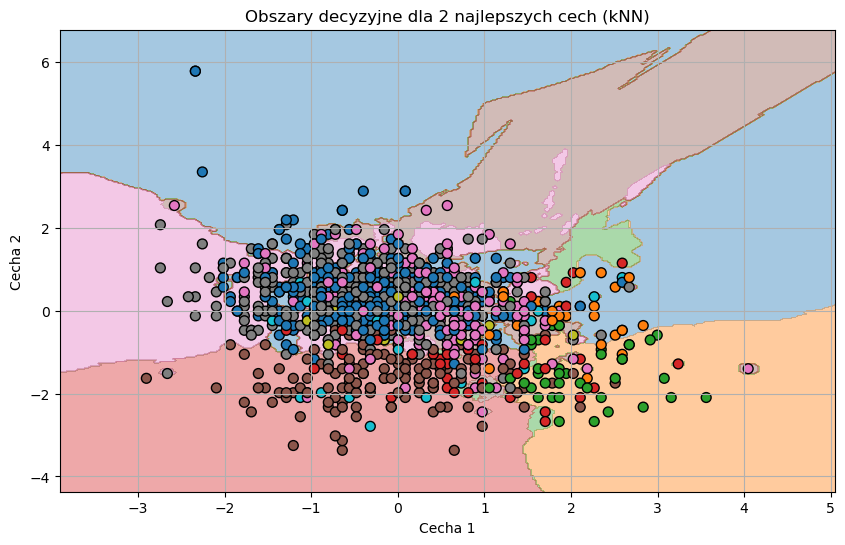

In [ ]:
x_min, x_max = X_train_best2[:, 0].min() - 1, X_train_best2[:, 0].max() + 1
y_min, y_max = X_train_best2[:, 1].min() - 1, X_train_best2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = knn_best2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap

plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(plt.cm.get_cmap('tab10').colors[:len(np.unique(y_train))])
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
plt.scatter(X_train_best2[:, 0], X_train_best2[:, 1], c=y_train, edgecolor='k', cmap='tab10', s=50)
plt.title("Obszary decyzyjne dla 2 najlepszych cech (kNN)")
plt.xlabel(f"Cechа {best_two_features[0]}")
plt.ylabel(f"Cechа {best_two_features[1]}")
plt.grid(True)
plt.show()

[KOMENTARZ] 8. W naszym przypadku klasyfikator kNN poradził sobie stosunkowo słabo. Ten algorytm ma trudności z niezbalansowanymi zbiorami danych, co potwierdziły niskie wyniki dla rzadkich klas. Przeszukiwanie siatki parametrów (GridSearchCV) oraz selekcja cech nie poprawiły wyników w istotny sposób. Choć kNN może być dobrym punktem wyjścia ze względu na prostotę implementacji, w tym zadaniu warto rozważyć zastosowanie innego klasyfikatora.